In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from sklearn.mixture import GaussianMixture
from data.data_loader import DataLoader  
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import numpy as np
import scipy.cluster.hierarchy as sch
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from collections import Counter

In [74]:
num_clusters = 50 # hard coded
linkage_methods = ['complete', 'average', 'weighted', 'median', 'centroid', 'ward']
csv_path = "../data/processed/wind-farms.csv"  

df_points = pd.read_csv(csv_path)


df_operating = df_points[df_points["Development Status"] == "Operating"]
lon_col = 'Longitude'
lat_col = 'Latitude'

special_points = list(zip(df_operating[lon_col], df_operating[lat_col]))

In [75]:
print("Loading data...")
loader = DataLoader("../data/raw")
lsmdf, lsmc, rlsmcs5Wmnavg = loader.load_wind_correlation_data()
print("Data loaded")

Loading data...
Data loaded


In [76]:
def compute_idxmap_gmm(lsmc, data, num_clusters, pca_components=50):
    from sklearn.decomposition import PCA
    data = data.astype(np.float32)
    pca = PCA(n_components=pca_components, random_state=29)
    data_reduced = pca.fit_transform(data)
    X_scaled = StandardScaler().fit_transform(data_reduced)
    gmm = GaussianMixture(n_components=num_clusters, random_state=29)
    labels = gmm.fit_predict(X_scaled)
    idxmap = np.full(lsmc.size, np.nan)
    active_idxs = np.flatnonzero(lsmc.flatten() == 1)
    idxmap[active_idxs] = labels + 1  # +1 per evitare etichetta 0
    
    return idxmap.reshape(lsmc.shape)

def compute_idxmap_spectral(lsmc, data, num_clusters):
    active_idxs = np.flatnonzero(lsmc.flatten() == 1)
    X_scaled = StandardScaler().fit_transform(data)
    sc = SpectralClustering(n_clusters=num_clusters, affinity='nearest_neighbors', random_state=29, n_neighbors=20)
    labels = sc.fit_predict(X_scaled)
    idxmap = np.full(lsmc.size, np.nan)
    idxmap[active_idxs] = labels + 1 
    return idxmap.reshape(lsmc.shape)

def compute_idxmap(lsmc, data, method, num_clusters):
    distances = pairwise_distances(data)
    linkage_matrix = sch.linkage(squareform(distances.astype('float32')), method=method)
    labels = sch.fcluster(linkage_matrix, num_clusters, criterion='maxclust')
    idxmap = np.full(lsmc.size, np.nan)
    active_idxs = np.flatnonzero(lsmc.flatten() == 1)
    idxmap[active_idxs] = labels
    return idxmap.reshape(lsmc.shape)

def compute_idxmap_kmeans(lsmc, data, num_clusters):
    X_scaled = StandardScaler().fit_transform(data)
    kmeans = KMeans(n_clusters=num_clusters, random_state=29)
    labels = kmeans.fit_predict(X_scaled)
    idxmap = np.full(lsmc.size, np.nan)
    active_idxs = np.flatnonzero(lsmc.flatten() == 1)
    idxmap[active_idxs] = labels + 1  
    return idxmap.reshape(lsmc.shape)


In [77]:
idxmap_dict = {}

In [78]:
for method in linkage_methods:
    print(f"Clustering con metodo {method}")
    idxmap_dict[method] = compute_idxmap(lsmc, rlsmcs5Wmnavg, method, num_clusters)

Clustering con metodo complete
Clustering con metodo average
Clustering con metodo weighted
Clustering con metodo median
Clustering con metodo centroid
Clustering con metodo ward


In [79]:
print("Clustering con KMeans")
idxmap_dict['kmeans'] = compute_idxmap_kmeans(lsmc, rlsmcs5Wmnavg, num_clusters=50)

Clustering con KMeans


In [80]:
print("Clustering con Spectral")
idxmap_dict['spectral'] = compute_idxmap_spectral(lsmc, rlsmcs5Wmnavg, num_clusters=50)

Clustering con Spectral


C:\Users\bizza\Desktop\XGeoAI\venv\Lib\site-packages\sklearn\cluster\_spectral.py:703: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(


In [81]:
print("Clustering con GMM")
idxmap_dict['gmm'] = compute_idxmap_gmm(lsmc, rlsmcs5Wmnavg, num_clusters)

Clustering con GMM


In [82]:
def plot_clusters_with_points(lsmdf, idxmap_dict, special_points, num_clusters=50, cols_per_row=2, methods_to_plot=None):
    # Se methods_to_plot non è fornito, prendi tutti i metodi
    methods = methods_to_plot if methods_to_plot is not None else idxmap_dict.keys()
    
    # Filtra idxmap_dict per considerare solo i metodi specificati
    filtered_idxmap = {m: idxmap_dict[m] for m in methods if m in idxmap_dict}

    n = len(filtered_idxmap)
    rows = int(np.ceil(n / cols_per_row))

    fig, axes = plt.subplots(rows, cols_per_row, figsize=(6 * cols_per_row, 5 * rows), constrained_layout=True)
    axes = axes.flatten() if n > 1 else [axes]

    for ax, (method, idxmap) in zip(axes, filtered_idxmap.items()):
        im = ax.pcolor(lsmdf.longitude, lsmdf.latitude, idxmap, cmap='tab20',
                       vmin=0.5, vmax=num_clusters + 0.5)

        if special_points:
            lons, lats = zip(*special_points)
            ax.scatter(lons, lats, color='black', s=10, marker='o')

        ax.set_title(f"Method: {method}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Rimuovi assi inutilizzati se ci sono
    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.show()

In [99]:
def summarize_special_points_distribution(lsmdf, idxmap_dict, special_points, top_n=5):
    print("Classifica dei cluster per densità di punti speciali:\n")

    for method, idxmap in idxmap_dict.items():

        
        
        cluster_ids = []

        for lon, lat in special_points:
            x_idx = (np.abs(lsmdf.longitude - lon)).argmin()
            y_idx = (np.abs(lsmdf.latitude - lat)).argmin()

            cluster_id = idxmap[y_idx, x_idx]
            if not np.isnan(cluster_id):
                cluster_ids.append(int(cluster_id))

        total_points = len(special_points)
        valid_points = len(cluster_ids)
        unique_clusters = len(set(cluster_ids))
        cluster_counts = Counter(cluster_ids)
        sorted_counts = sorted(cluster_counts.values(), reverse=True)
        total_clusters = len(np.unique(idxmap[~np.isnan(idxmap)]))

        top_counts = sorted_counts[:top_n]
        cumulative = sum(top_counts)
        cumulative_percent = 100 * cumulative / valid_points if valid_points > 0 else 0

        print(f"Metodo: {method}")
        print(f"   - Cluster totali nella mappa: {total_clusters}")
        print(f"   - Punti totali: {total_points}")
        print(f"   - Punti validi (in cluster): {valid_points}")
        print(f"   - Distribuiti su {unique_clusters} cluster diversi")
        print(f"   - Top {top_n} cluster contengono il {cumulative_percent:.1f}% dei punti")
        print("")


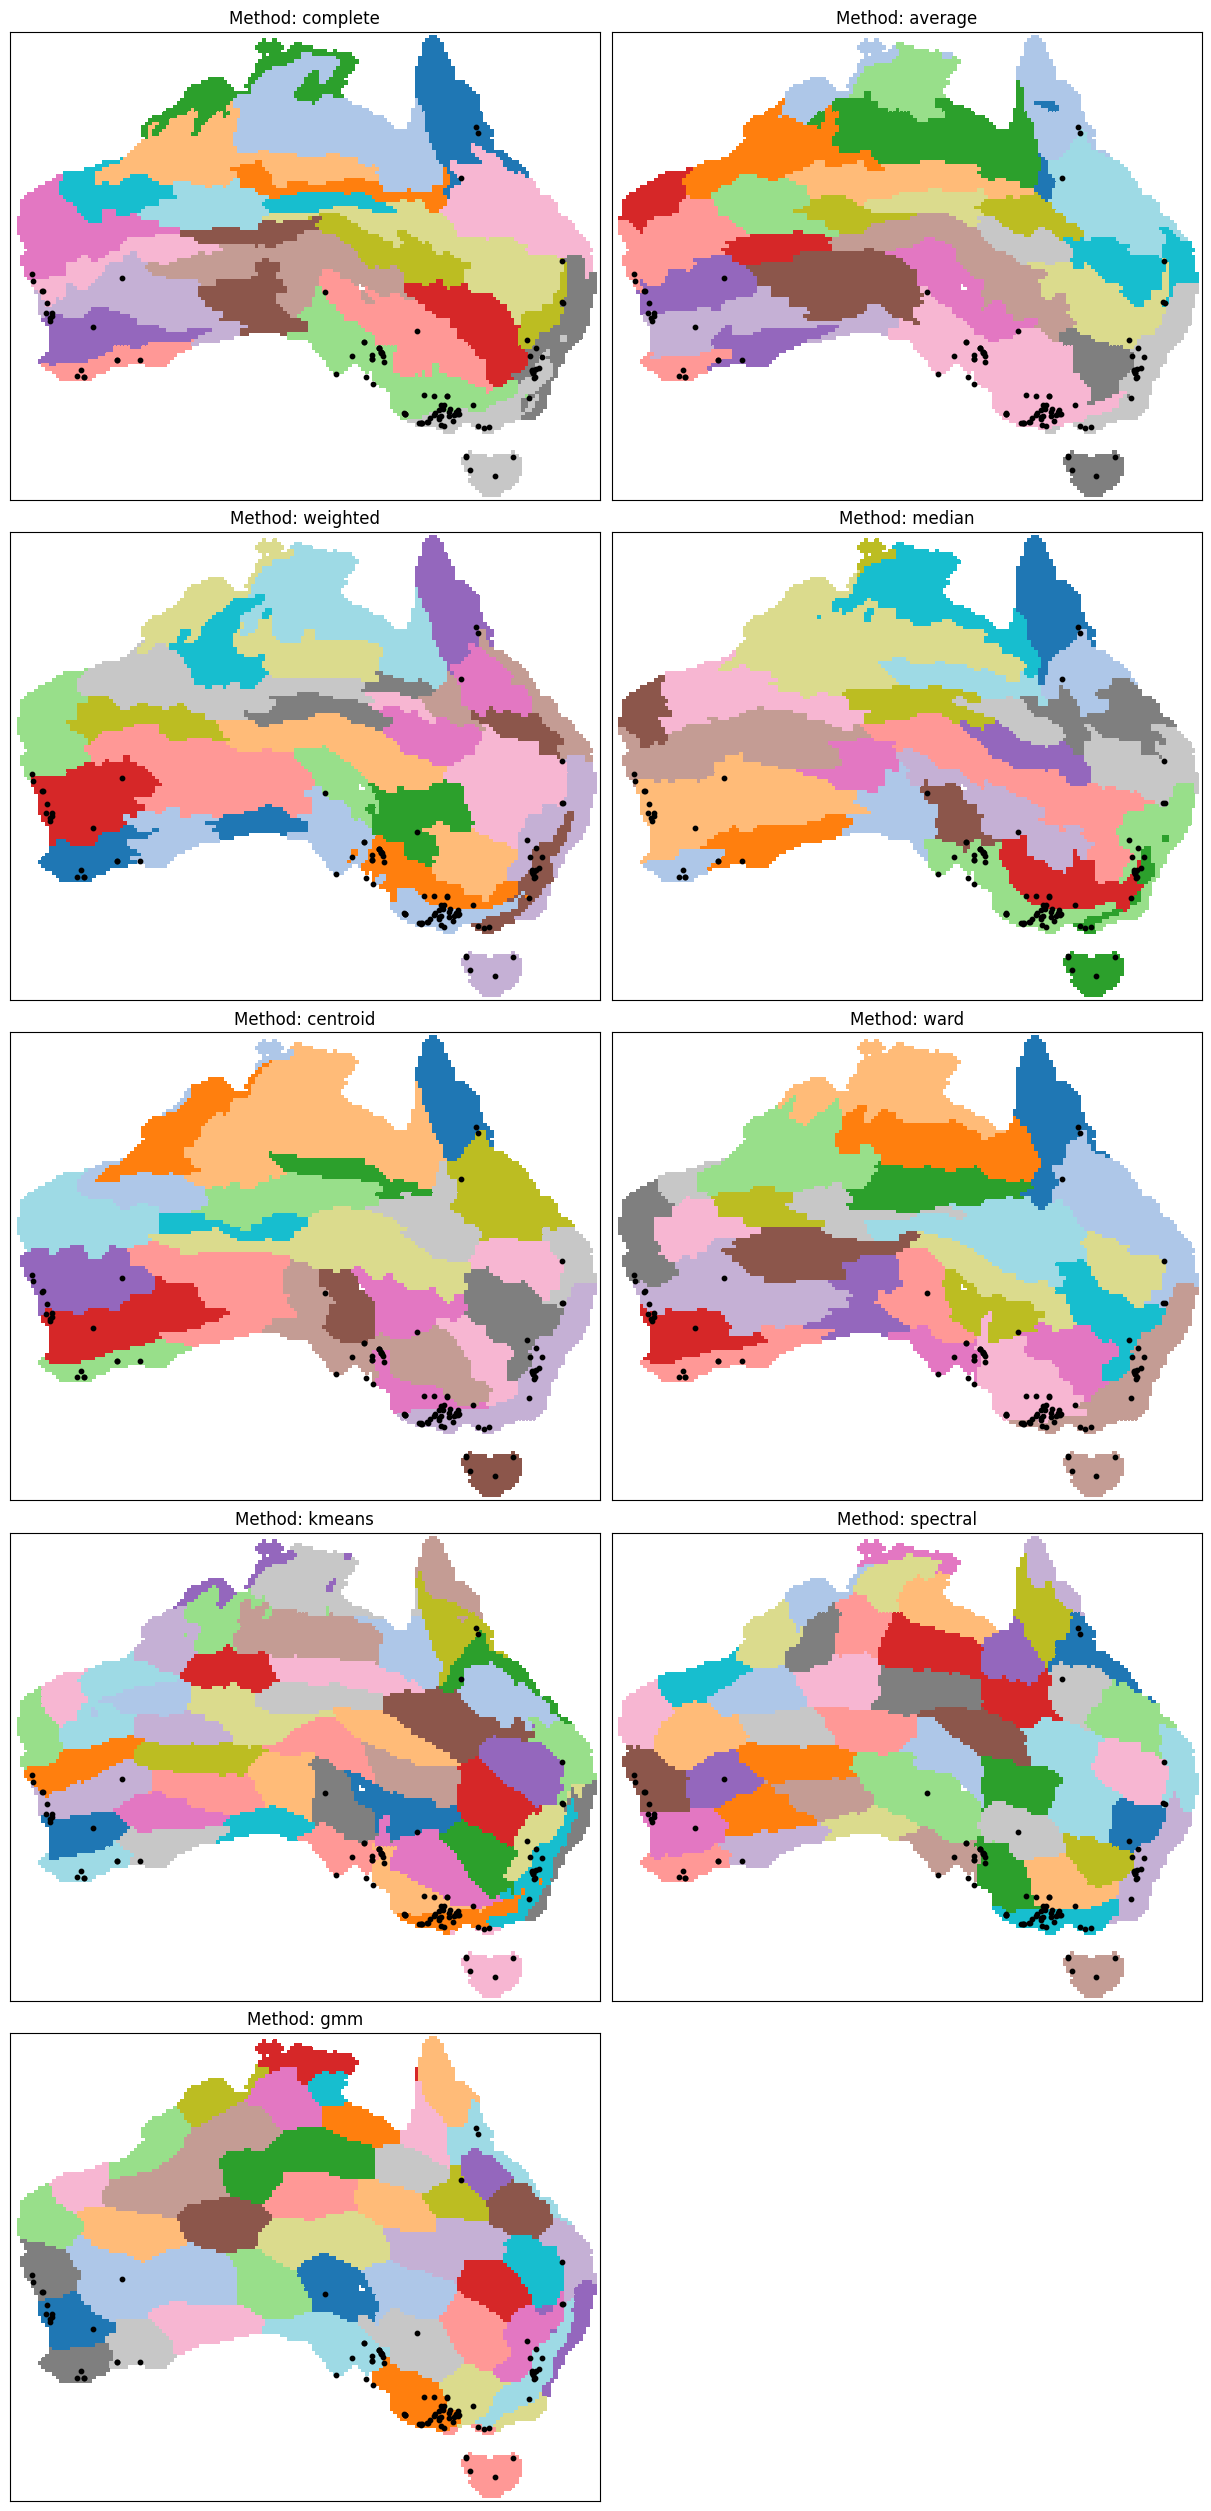

In [84]:
plot_clusters_with_points(lsmdf, idxmap_dict, special_points)

In [100]:
summarize_special_points_distribution(lsmdf, idxmap_dict, special_points, top_n=5)

Classifica dei cluster per densità di punti speciali:

Metodo: complete
   - Cluster totali nella mappa: 50
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 16 cluster diversi
   - Top 5 cluster contengono il 71.8% dei punti

Metodo: average
   - Cluster totali nella mappa: 50
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 15 cluster diversi
   - Top 5 cluster contengono il 72.8% dei punti

Metodo: weighted
   - Cluster totali nella mappa: 50
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 16 cluster diversi
   - Top 5 cluster contengono il 73.8% dei punti
Metodo: median
   - Cluster totali nella mappa: 50
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 19 cluster diversi
   - Top 5 cluster contengono il 65.0% dei punti

Metodo: centroid
   - Cluster totali nella mappa: 50
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 18 cluster di